In [63]:
import torch
from compressai.models import DCAE, TCM
import compressai.runtime.utils.metrics as metrics
import numpy as np
import torch.nn.functional as F
from compressai.utils import dataloader_science
from compressai.zoo import bmshj2018_factorized

from compressai.runtime import build_runtime
from compressai.runtime.config import RuntimeConfig
from compressai.runtime.codecs import GpuPackedEntropyCodec
from compressai.runtime.utils.benchmark import run_e2e

# config
quality = 8
dataset = "nyx"
bin_path = "/hwj/data/caiec_test_data/nyx_log_512x1x512x512.f32"
input_shape = (512, 512, 512)            # (N,H,W)
block_size = (3, 512, 512)            # (bn,3,bh,bw)
p=0.95
stride = (int(block_size[1] * p), int(block_size[2] * p))
device = "cuda:0"
batchsize = 90
norm_type = "minmax"
pad_value = 0.5

blocks, x_nhw_ori, status, meta = dataloader_science.blockify_bin_overlap(
    bin_path, input_shape, block_size, p, stride_hw=stride,
    dtype=np.float32, pad_value=pad_value, norm_type=norm_type, device=device
)
bn = blocks.shape[0]

net = bmshj2018_factorized(quality=quality)
net = net.to(device)
net.eval()

checkpoint = torch.load(f"/hwj/data/bmshj2018-factorized/bmshj2018-factorized-{quality}.pth", map_location=device)
# for k, v in checkpoint["state_dict"].items():
#     dictory[k.replace("module.", "")] = v
net.load_state_dict(checkpoint)
net.update()   

codec = GpuPackedEntropyCodec(
    net.entropy_bottleneck,
    P=1
)

cfg = RuntimeConfig(
    model_name="bmshj2018_factorized",
    ga_input_dtype=torch.float32,
    gs_input_dtype=torch.float16,
    codec_input_dtype=torch.float32,
    trt_engines={
        "ga":f"/hwj/data/engines/bmshj2018-factorized/q{quality}/engines/{dataset}/ga/fp8.engine",
        "gs":f"/hwj/data/engines/bmshj2018-factorized/q{quality}/engines/{dataset}/gs/fp16.engine",
    },
)

engine = build_runtime(net, codec, cfg)

xhat_blocks = torch.empty_like(blocks)
bit_len = 0
strings_bytes_list = []
state_bytes_list = []

cmp_time_lists = []
decmp_time_lists = []

enc_start = torch.cuda.Event(enable_timing=True)
enc_end   = torch.cuda.Event(enable_timing=True)
dec_start = torch.cuda.Event(enable_timing=True)
dec_end   = torch.cuda.Event(enable_timing=True)

input = blocks[:batchsize]  
# warmup
for i in range(5):
    pack = engine.compress(input)
torch.cuda.synchronize()

# inference
with torch.no_grad():
    for start in range(0, bn, batchsize):
        end = min(start + batchsize, bn)
        print(f"Processing blocks {start} to {end} / {bn}")
        input = blocks[start:end]   
        cur_bs = input.shape[0]
        if cur_bs < batchsize:
            pad_bs = batchsize - cur_bs
            pad_shape = (pad_bs,) + input.shape[1:]
            pad = torch.full(
                pad_shape,
                0.5,
                dtype=input.dtype,
                device=input.device,
            )
            input = torch.cat([input, pad], dim=0)
            print("input pad to:", input.shape)   

        enc_start.record()
        pack,_,_ = engine.compress_time(input)
        enc_end.record()
        torch.cuda.synchronize()
        cmp_time_lists.append(enc_start.elapsed_time(enc_end))
        
        dec_start.record()
        x_hat,_,_ = engine.decompress_time(pack)
        dec_end.record()
        torch.cuda.synchronize()
        decmp_time_lists.append(dec_start.elapsed_time(dec_end))
        
        if hasattr(codec, "pack_bytes"):
            b = codec.pack_bytes(pack)
            strings_bytes_list.append(float(b.get("strings_bytes", 0.0)))
            state_bytes_list.append(float(b.get("state_bytes", 0.0)))
        xhat_blocks[start:end] = x_hat[:cur_bs]
        del input, pack, x_hat
        torch.cuda.empty_cache()
        
assert xhat_blocks.shape[0] == bn
strings_bytes = sum(strings_bytes_list)
state_bytes = sum(state_bytes_list)
bit_len = strings_bytes + state_bytes
x_hat_nhw = dataloader_science.blocks_to_nhw_overlap_weighted(
    xhat_blocks,
    input_shape,
    block_size,
    stride_hw=stride,
    meta_hw=meta,
    pad_value=pad_value,
    norm_type="minmax",
    vmin=status["vmin"],
    vmax=status["vmax"],
    vmean=status["vmean"],
    vstd=status["vstd"],
)

# compute metrics
metr = metrics.basic_metrics(x_hat_nhw, x_nhw_ori)
num_pixels = x_nhw_ori.size(0) * x_nhw_ori.size(1) * x_nhw_ori.size(2)
bit_rate = bit_len * 8.0 / num_pixels

# thr
ori_size = x_nhw_ori.numel() * x_nhw_ori.element_size()
cmpthr = ori_size / 1024 / 1024 / 1024 / (sum(cmp_time_lists) / 1000)
decmpthr = ori_size / 1024 / 1024 / 1024 / (sum(decmp_time_lists) / 1000)

print("bpp:", bit_rate)
print("rmse:", metr["rmse"])
print("nrmse:", metr["nrmse"])
print("maxe:", metr["maxe"])
print("psnr:", metr["psnr"])
print("Compress Throughput:", cmpthr, "GB/s")
print("Decompress Throughput:", decmpthr, "GB/s")

[03/24/2026-10:13:38] [TRT] [W] Using an engine plan file across different models of devices is not supported and is likely to affect performance or even cause errors or deadlock.
[03/24/2026-10:13:38] [TRT] [W] Using an engine plan file across different models of devices is not supported and is likely to affect performance or even cause errors or deadlock.
[03/24/2026-10:13:38] [TRT] [W] Using default stream in enqueueV3() may lead to performance issues due to additional calls to cudaStreamSynchronize() by TensorRT to ensure correct synchronization. Please use non-default stream instead.
Processing blocks 0 to 90 / 171
[03/24/2026-10:13:38] [TRT] [W] Using default stream in enqueueV3() may lead to performance issues due to additional calls to cudaStreamSynchronize() by TensorRT to ensure correct synchronization. Please use non-default stream instead.
Processing blocks 90 to 171 / 171
input pad to: torch.Size([90, 3, 512, 512])
bpp: 1.2077710628509521
rmse: 1.829214096069336
nrmse: 0.0

===== Residual Statistics =====
shape: (40, 2048, 2048)
dtype: torch.float32
max: 0.0015536564169451594
min: -0.0016250169137492776
mean: 2.722068757066154e-06
std: 9.635082096792758e-05
abs mean: 7.402972551062703e-05
abs max: 0.0016250169137492776
median: 5.5381597121595405e-06
mse: 9.290890723434586e-09
rmse: 9.638926664019488e-05


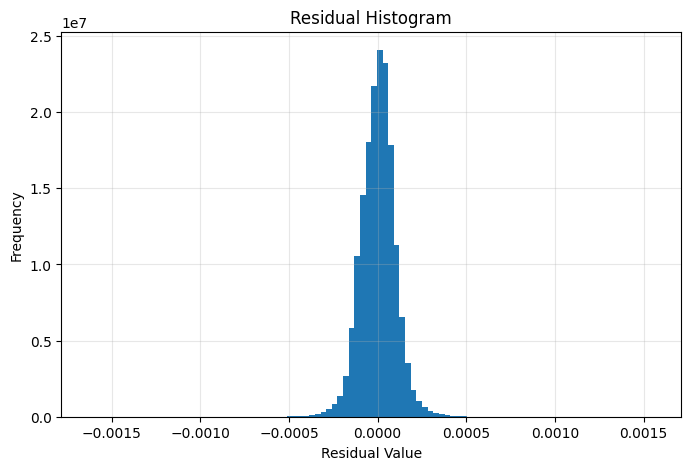

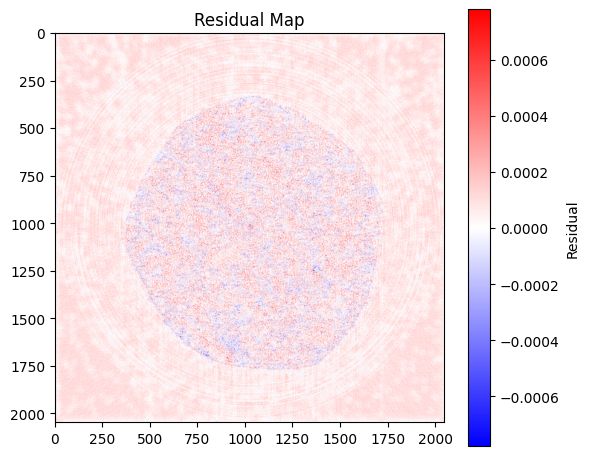

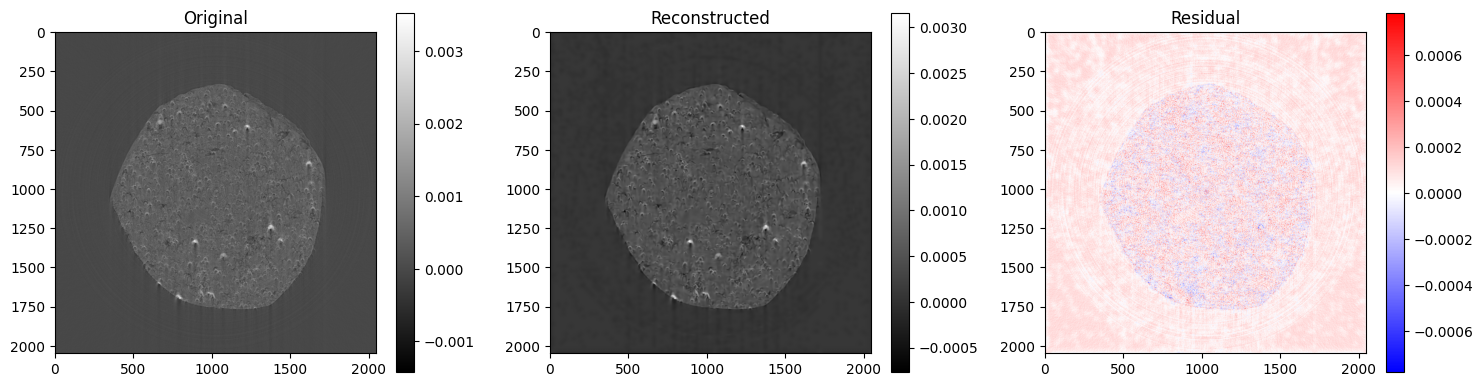

In [9]:
import torch
import matplotlib.pyplot as plt

# 残差
diff = x_hat_nhw - x_nhw_ori

# =========================
# 1. 数值统计
# =========================
print("===== Residual Statistics =====")
print("shape:", tuple(diff.shape))
print("dtype:", diff.dtype)

print("max:", diff.max().item())
print("min:", diff.min().item())
print("mean:", diff.mean().item())
print("std:", diff.std().item())
print("abs mean:", diff.abs().mean().item())
print("abs max:", diff.abs().max().item())
print("median:", diff.median().item())

# 可选：均方误差 / RMSE
mse = (diff ** 2).mean().item()
rmse = mse ** 0.5
print("mse:", mse)
print("rmse:", rmse)

# 可选：分位数
diff_flat = diff.detach().flatten().float().cpu()
# q = torch.quantile(diff_flat, torch.tensor([0.01, 0.05, 0.5, 0.95, 0.99]))
# print("quantiles:")
# print("  1% :", q[0].item())
# print("  5% :", q[1].item())
# print("  50%:", q[2].item())
# print("  95%:", q[3].item())
# print("  99%:", q[4].item())


# =========================
# 2. 残差频率分布图（直方图）
# =========================
plt.figure(figsize=(8, 5))
plt.hist(diff_flat.numpy(), bins=100)
plt.title("Residual Histogram")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()


# =========================
# 3. 残差可视化
# =========================
# 如果 diff 是 [N, H, W]，取第一个样本画
# 如果 diff 是 [H, W]，直接画
diff_vis = diff.detach().cpu()

if diff_vis.ndim == 3:
    img = diff_vis[0]
elif diff_vis.ndim == 2:
    img = diff_vis
else:
    img = None
    print("diff is not 2D/3D, skip spatial visualization.")

if img is not None:
    plt.figure(figsize=(6, 5))
    plt.imshow(img.numpy(), cmap="bwr")
    plt.colorbar(label="Residual")
    plt.title("Residual Map")
    plt.tight_layout()
    plt.show()


# =========================
# 4. 原图 / 重建图 / 残差图对比
# =========================
x_ori_vis = x_nhw_ori.detach().cpu()
x_hat_vis = x_hat_nhw.detach().cpu()

if x_ori_vis.ndim == 3:
    ori_img = x_ori_vis[0]
    hat_img = x_hat_vis[0]
    diff_img = diff_vis[0]
elif x_ori_vis.ndim == 2:
    ori_img = x_ori_vis
    hat_img = x_hat_vis
    diff_img = diff_vis
else:
    ori_img = hat_img = diff_img = None
    print("input is not 2D/3D, skip comparison visualization.")

if ori_img is not None:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(ori_img.numpy(), cmap="gray")
    plt.title("Original")
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(hat_img.numpy(), cmap="gray")
    plt.title("Reconstructed")
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow(diff_img.numpy(), cmap="bwr")
    plt.title("Residual")
    plt.colorbar()

    plt.tight_layout()
    plt.show()


# Error Bounded Module

In [2]:
import math
import numpy as np
import torch
import cupy as cp
from nvidia import nvcomp


class ErrorBoundedNvcompCompressor:
    """
    Error-bounded residual compressor:
      diff --(quantize with absolute error bound)--> q
           --(view as bytes)--> nvCOMP lossless compression

    支持:
      - torch CUDA tensor 输入
      - 压缩 / 解压
      - 记录压缩字节数、压缩比
      - 校验误差上界
    """

    _TORCH_TO_NUMPY = {
        torch.int8: np.int8,
        torch.int16: np.int16,
        torch.int32: np.int32,
        torch.int64: np.int64,
    }

    _NUMPY_STR_TO_TORCH = {
        "int8": torch.int8,
        "int16": torch.int16,
        "int32": torch.int32,
        "int64": torch.int64,
    }

    def __init__(self, error_bound: float, algorithm: str = "Zstd", bitstream_kind=None):
        """
        error_bound: 逐点绝对误差上界
        algorithm: nvCOMP 算法名，如 "Zstd", "LZ4", "GDeflate", "ANS", "Bitcomp"
        bitstream_kind: 可选，默认走 nvCOMP 默认设置
        """
        assert error_bound > 0, "error_bound must be > 0"
        self.error_bound = float(error_bound)
        self.step = 2.0 * self.error_bound

        if bitstream_kind is None:
            self.codec = nvcomp.Codec(algorithm=algorithm)
        else:
            self.codec = nvcomp.Codec(algorithm=algorithm, bitstream_kind=bitstream_kind)

        self.algorithm = algorithm

    @staticmethod
    def _torch_to_cupy_zero_copy(x: torch.Tensor) -> cp.ndarray:
        """Torch CUDA tensor -> CuPy zero-copy"""
        assert x.is_cuda, "input tensor must be on CUDA"
        return cp.from_dlpack(torch.utils.dlpack.to_dlpack(x))

    @staticmethod
    def _cupy_to_torch_zero_copy(x: cp.ndarray) -> torch.Tensor:
        """CuPy array -> Torch zero-copy"""
        return torch.utils.dlpack.from_dlpack(x.toDlpack())

    @staticmethod
    def _choose_q_dtype(q_min: int, q_max: int):
        if -128 <= q_min and q_max <= 127:
            return torch.int8
        elif -32768 <= q_min and q_max <= 32767:
            return torch.int16
        elif -2147483648 <= q_min and q_max <= 2147483647:
            return torch.int32
        else:
            return torch.int64

    def quantize(self, diff: torch.Tensor):
        """
        对残差量化，保证 |diff_hat - diff| <= error_bound
        返回:
          q        : 整数量化结果
          diff_hat : 量化重建残差
        """
        assert torch.is_tensor(diff), "diff must be a torch tensor"
        assert diff.is_cuda, "diff must be on CUDA"

        diff_f = diff.float()
        q64 = torch.round(diff_f / self.step).to(torch.int64)

        q_min = int(q64.min().item())
        q_max = int(q64.max().item())
        q_dtype = self._choose_q_dtype(q_min, q_max)
        q = q64.to(q_dtype)

        diff_hat = q.float() * self.step
        max_abs_err = (diff_hat - diff_f).abs().max().item()

        meta = {
            "error_bound": self.error_bound,
            "step": self.step,
            "q_dtype": str(q.dtype).replace("torch.", ""),
            "q_min": q_min,
            "q_max": q_max,
            "max_abs_error_after_quant": float(max_abs_err),
        }
        return q, diff_hat, meta

    def compress(self, diff: torch.Tensor):
        """
        输入:
          diff: torch CUDA tensor

        返回 dict:
          {
            "compressed_bytes": bytes,
            "meta": {...},
            "stats": {...},
            "q": q,                      # 可选调试
            "diff_hat": diff_hat         # 可选调试
          }
        """
        q, diff_hat, qmeta = self.quantize(diff)

        # q 视为字节流进行无损压缩
        q_cp = self._torch_to_cupy_zero_copy(q.contiguous())
        q_bytes_view = q_cp.view(cp.uint8).reshape(-1)

        nv_in = nvcomp.as_array(q_bytes_view)
        comp_arr = self.codec.encode(nv_in)

        # compressed size
        compressed_nbytes = int(comp_arr.buffer_size)
        original_nbytes = int(q_bytes_view.nbytes)

        # 拷回 host 形成可保存的 bytes
        comp_cp = cp.asarray(comp_arr)
        compressed_bytes = cp.asnumpy(comp_cp).tobytes()

        stats = {
            "original_nbytes": original_nbytes,
            "compressed_nbytes": compressed_nbytes,
            "compression_ratio": (original_nbytes / compressed_nbytes) if compressed_nbytes > 0 else math.inf,
            "compressed_fraction": (compressed_nbytes / original_nbytes) if original_nbytes > 0 else 0.0,
        }

        meta = {
            "algorithm": self.algorithm,
            "error_bound": self.error_bound,
            "step": self.step,
            "shape": list(q.shape),
            "q_dtype": str(q.dtype).replace("torch.", ""),
            "device": str(diff.device),
        }
        meta.update(qmeta)

        return {
            "compressed_bytes": compressed_bytes,
            "meta": meta,
            "stats": stats,
            "q": q,
            "diff_hat": diff_hat,
        }

    def decompress(self, compressed_bytes: bytes, meta: dict, device: str = "cuda"):
        """
        解压并反量化，返回:
          q_rec, diff_rec
        """
        assert isinstance(compressed_bytes, (bytes, bytearray))

        shape = tuple(meta["shape"])
        q_dtype_str = meta["q_dtype"]
        step = float(meta["step"])

        if q_dtype_str not in self._NUMPY_STR_TO_TORCH:
            raise ValueError(f"Unsupported q dtype: {q_dtype_str}")

        q_torch_dtype = self._NUMPY_STR_TO_TORCH[q_dtype_str]
        q_np_dtype = self._TORCH_TO_NUMPY[q_torch_dtype]

        # host bytes -> host uint8 -> device uint8
        comp_np = np.frombuffer(compressed_bytes, dtype=np.uint8)
        nv_comp = nvcomp.as_array(comp_np).cuda()

        # nvCOMP decode
        nv_dec = self.codec.decode(nv_comp)

        # decoded bytes -> cupy uint8
        dec_cp_u8 = cp.asarray(nv_dec)

        # reinterpret as q dtype
        q_cp = dec_cp_u8.view(q_np_dtype).reshape(shape)
        q_rec = self._cupy_to_torch_zero_copy(q_cp).to(device=device)

        diff_rec = q_rec.float() * step
        return q_rec, diff_rec

    def compress_and_report(self, diff: torch.Tensor, verbose: bool = True):
        out = self.compress(diff)

        if verbose:
            print("===== Error-Bounded nvCOMP Compression Report =====")
            print("algorithm           :", out["meta"]["algorithm"])
            print("error_bound         :", out["meta"]["error_bound"])
            print("step                :", out["meta"]["step"])
            print("shape               :", out["meta"]["shape"])
            print("q_dtype             :", out["meta"]["q_dtype"])
            print("q_min               :", out["meta"]["q_min"])
            print("q_max               :", out["meta"]["q_max"])
            print("max_abs_err_quant   :", out["meta"]["max_abs_error_after_quant"])
            print("original_nbytes     :", out["stats"]["original_nbytes"])
            print("compressed_nbytes   :", out["stats"]["compressed_nbytes"])
            print("compression_ratio   :", out["stats"]["compression_ratio"])
            print("compressed_fraction :", out["stats"]["compressed_fraction"])

        return out


1. verify difference compression

In [66]:
diff = x_hat_nhw - x_nhw_ori
compressor = ErrorBoundedNvcompCompressor(
    error_bound=1e-1,
    algorithm="Zstd",   # 也可以换成 "LZ4", "GDeflate", "ANS", "Bitcomp"
)

result = compressor.compress_and_report(diff)

compressed_bytes = result["compressed_bytes"]
meta = result["meta"]
stats = result["stats"]
diff_hat = result["diff_hat"]

print("compressed bytes len:", len(compressed_bytes))
print("compression ratio:", stats["compression_ratio"])


===== Error-Bounded nvCOMP Compression Report =====
algorithm           : Zstd
error_bound         : 0.1
step                : 0.2
shape               : [512, 512, 512]
q_dtype             : int16
q_min               : -132
q_max               : 132
max_abs_err_quant   : 0.10000038146972656
original_nbytes     : 268435456
compressed_nbytes   : 110745587
compression_ratio   : 2.4238930260941234
compressed_fraction : 0.41255946084856987
compressed bytes len: 110745587
compression ratio: 2.4238930260941234


2. end-to-end performance

In [67]:
x_er_nhw = x_hat_nhw - diff_hat
# 校验误差上界
max_abs_err = (x_er_nhw - x_nhw_ori).abs().max().item()
print("max absolute error after ER:", max_abs_err)  

# compute metrics
metr = metrics.basic_metrics(x_er_nhw, x_nhw_ori)
num_pixels = x_nhw_ori.size(0) * x_nhw_ori.size(1) * x_nhw_ori.size(2)
bit_rate = (len(compressed_bytes) * 8 + bit_len * 8.0) / num_pixels
cr = (x_nhw_ori.numel() * x_nhw_ori.element_size()) / (len(compressed_bytes) + bit_len)

print("===== ER-Bounded Compression Metrics =====")
print("bpp (including ER bytes):", bit_rate)
print("compression ratio (including ER bytes):", cr)
print("rmse:", metr["rmse"])
print("nrmse:", metr["nrmse"])
print("maxe:", metr["maxe"])
print("psnr:", metr["psnr"])


max absolute error after ER: 0.10000061988830566
===== ER-Bounded Compression Metrics =====
bpp (including ER bytes): 7.80872243642807
compression ratio (including ER bytes): 4.097981489355857
rmse: 0.05773502588272095
nrmse: 0.0019423644989728928
maxe: 0.10000061988830566
psnr: 54.230682373046875


3. baseline

In [62]:
import numpy as np
import torch

cuszhi_path = "/hwj/data/caiec_test_data/nyx_log_512x1x512x512.f32.pfplx"

shape = (512, 512, 512)

# 读取重建数据
x_cuszhi_nhw = np.fromfile(cuszhi_path, dtype=np.float32).reshape(shape)

# 转 torch
x_cuszhi_nhw = torch.from_numpy(x_cuszhi_nhw).cuda()

# 计算 metrics
metr = metrics.basic_metrics(x_cuszhi_nhw, x_nhw_ori)

print("===== Metrics =====")
print("rmse:", metr["rmse"])
print("nrmse:", metr["nrmse"])
print("maxe:", metr["maxe"])
print("psnr:", metr["psnr"])


===== Metrics =====
rmse: 1.7281309366226196
nrmse: 0.05816210061311722
maxe: 9.999985694885254
psnr: 24.693891525268555
